In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Physics utilities
# =========================

def energy(m0, m1, m2):
    return (m0**2 + m1**2 - m2**2) / (2 * m0)

def momentum(m0, m1, m2):
    return np.sqrt(np.maximum(energy(m0, m1, m2)**2 - m1**2, 0))


# =========================
# Angular generator
# =========================

def generate_angles(n):
    theta = np.arccos(1 - 2*np.random.rand(n))  # isotropic
    phi = 2 * np.pi * np.random.rand(n)
    return theta, phi

# =========================
# Two-body decay generator
# =========================



def two_body_decay(n, m0, m1, m2, label):
    """
    Generates n events of m0 → m1 + m2 in rest frame
    """
    E1 = energy(m0, m1, m2)
    E2 = energy(m0, m2, m1)
    p = momentum(m0, m1, m2)

    theta, phi = generate_angles(n)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,

        "E1": E1,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E2,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df

# =========================
# Gamma-gamma → X (mass spectrum)
# =========================

def sample_exponential_mass(n, m_min, m_max, scale):
    """
    Exponential spectrum between m_min and m_max
    """
    masses = []
    while len(masses) < n:
        x = np.random.exponential(scale)
        if m_min <= x <= m_max:
            masses.append(x)
    return np.array(masses)


def gamma_gamma_to_pair(n, m_particle, label, scale=1.0):
    """
    γγ → particle + antiparticle with exponential invariant mass
    """
    m_min = 2 * m_particle
    m_max = 7.0  # GeV

    m0 = sample_exponential_mass(n, m_min, m_max, scale)

    theta, phi = generate_angles(n)

    E = m0 / 2
    p = np.sqrt(np.maximum(E**2 - m_particle**2, 0))

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,
        "m_inv": m0,

        "E1": E,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df   

# =========================
# Masses (GeV)
# =========================

masses = {
    "Jpsi": 3.0969,
    "Psip": 3.686,
    "p": 0.938,
    "mu": 0.1057,
    "e": 0.000511,
    "K": 0.4937,
    "Phi" : 1.02
}


# =========================
# Generate datasets
# =========================

N = 20000

df_list = []

# J/ψ decays
df_list.append(two_body_decay(N, masses["Jpsi"], masses["p"], masses["p"], "Jpsi→pp"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["mu"], masses["mu"], "Jpsi→mumu"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["e"], masses["e"], "Jpsi→ee"))

# ψ' decays
df_list.append(two_body_decay(N, masses["Psip"], masses["mu"], masses["mu"], "Psip→mumu"))

#Phi decays
df_list.append(two_body_decay(N, masses["Phi"], masses["K"], masses["K"], "Phi→KK"))

# γγ processes
df_list.append(gamma_gamma_to_pair(N, masses["mu"], "γγ→mumu"))
df_list.append(gamma_gamma_to_pair(N, masses["e"], "γγ→ee"))
df_list.append(gamma_gamma_to_pair(N, masses["K"], "γγ→KK"))


df_list[0]


,process,E1,px1,py1,pz1,E2,px2,py2,pz2
0,Jpsi→pp,1.54845,0.656517,0.930624,0.469870,1.54845,-0.656517,-0.930624,-0.469870
1,Jpsi→pp,1.54845,0.171114,-1.084616,-0.558732,1.54845,-0.171114,1.084616,0.558732
2,Jpsi→pp,1.54845,0.862281,0.736709,0.481233,1.54845,-0.862281,-0.736709,-0.481233
3,Jpsi→pp,1.54845,-0.076336,-0.546554,1.101501,1.54845,0.076336,0.546554,-1.101501
4,Jpsi→pp,1.54845,1.190087,-0.067607,0.311409,1.54845,-1.190087,0.067607,-0.311409
...,...,...,...,...,...,...,...,...,...
19995,Jpsi→pp,1.54845,-1.162397,-0.389488,0.122414,1.54845,1.162397,0.389488,-0.122414
19996,Jpsi→pp,1.54845,0.455951,0.688851,-0.914027,1.54845,-0.455951,-0.688851,0.914027
19997,Jpsi→pp,1.54845,-1.151153,0.183904,0.398597,1.54845,1.151153,-0.183904,-0.398597
19998,Jpsi→pp,1.54845,0.491209,-0.982318,-0.558228,1.54845,-0.491209,0.982318,0.558228


# Smearing section and energy recomputing


In [116]:
#Smearing
def smear_momentum(df, sigma_rel=0.01):
    for comp in ["px1", "py1", "pz1", "px2", "py2", "pz2"]:
        sigma = sigma_rel * np.abs(df[comp])
        df[comp] = np.random.normal(df[comp], sigma)

    return df

df = pd.concat(df_list, ignore_index=True)

mass_map = {
    "Jpsi→pp": (masses["p"], masses["p"]),
    "Jpsi→mumu": (masses["mu"], masses["mu"]),
    "Jpsi→ee": (masses["e"], masses["e"]),
    "Psip→mumu": (masses["mu"], masses["mu"]),
    "Phi→KK": (masses["K"], masses["K"]),
    "γγ→mumu": (masses["mu"], masses["mu"]),
    "γγ→ee": (masses["e"], masses["e"]),
    "γγ→KK": (masses["K"], masses["K"]),
}
df["p1"] = np.sqrt(df["px1"]**2 + df["py1"]**2 + df["pz1"]**2)
df["p2"] = np.sqrt(df["px2"]**2 + df["py2"]**2 + df["pz2"]**2)

# Apply smearing
df = smear_momentum(df, sigma_rel=0.02)  # 2% resolution

def recompute_all_energies(df):
    for proc, (m1, m2) in mass_map.items():
        mask = df["process"] == proc

        p1_sq = df.loc[mask, ["px1","py1","pz1"]].pow(2).sum(axis=1)
        p2_sq = df.loc[mask, ["px2","py2","pz2"]].pow(2).sum(axis=1)

        df.loc[mask, "E1"] = np.sqrt(p1_sq + m1**2)
        df.loc[mask, "E2"] = np.sqrt(p2_sq + m2**2)

    return df



df_before = df.copy()

df_after = smear_momentum(df.copy(), sigma_rel= 0.04)
df_after = recompute_all_energies(df_after)

# Momentum comparisons

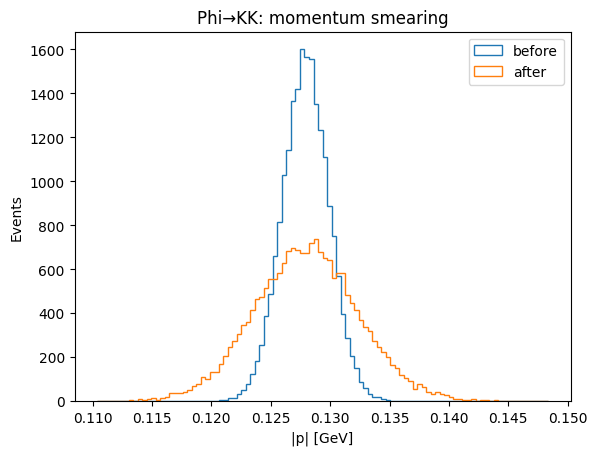

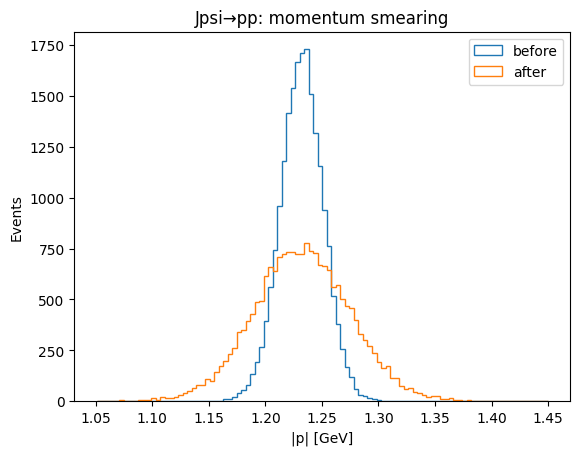

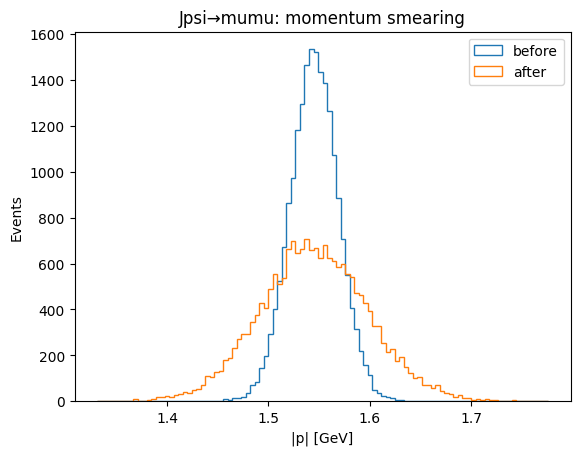

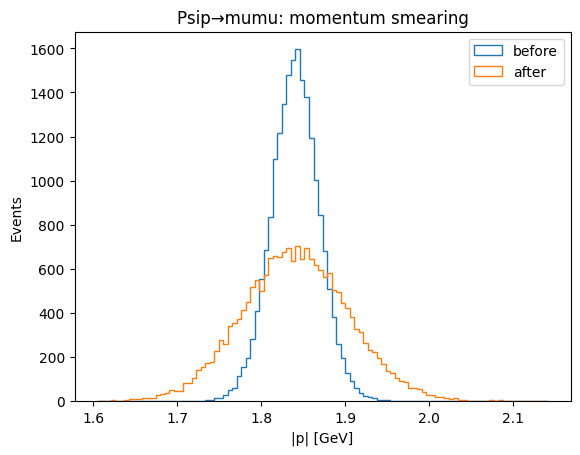

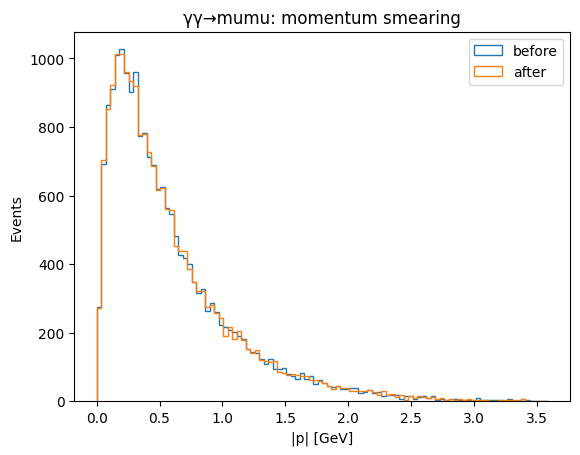

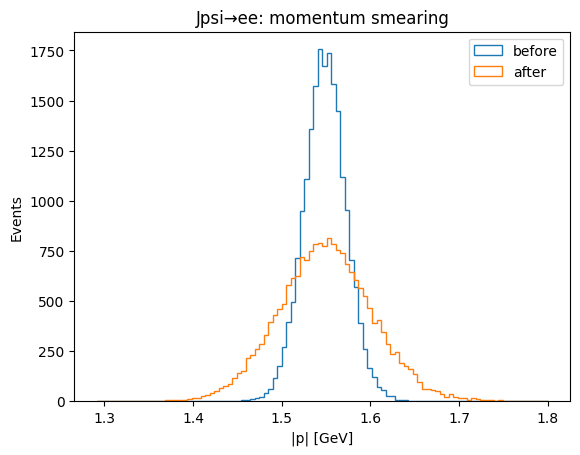

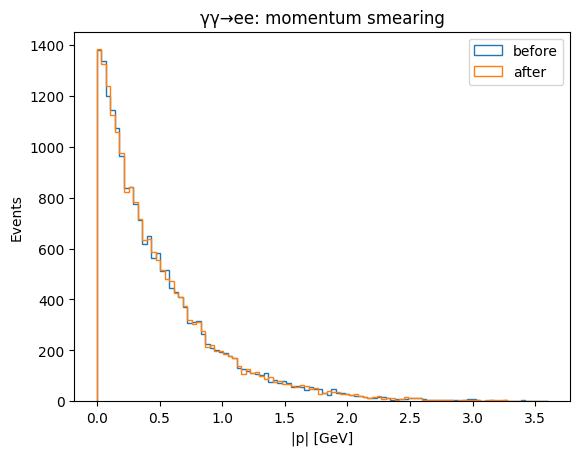

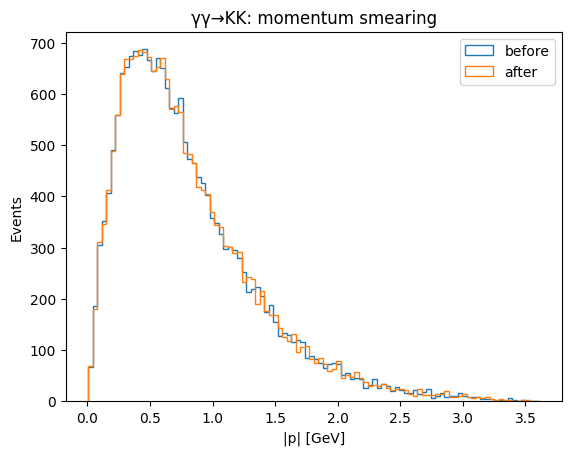

In [117]:
def plot_momentum_comparison(df_before, df_after, process):

    b = df_before[df_before["process"] == process]
    a = df_after[df_after["process"] == process]

    # compute |p|
    p1_b = np.sqrt(b["px1"]**2 + b["py1"]**2 + b["pz1"]**2)
    p1_a = np.sqrt(a["px1"]**2 + a["py1"]**2 + a["pz1"]**2)

    # clean
    p1_b = p1_b.replace([np.inf, -np.inf], np.nan).dropna()
    p1_a = p1_a.replace([np.inf, -np.inf], np.nan).dropna()

    if len(p1_b) == 0 or len(p1_a) == 0:
        print(f"{process}: no data")
        return

    # check spread
    pmin = min(p1_b.min(), p1_a.min())
    pmax = max(p1_b.max(), p1_a.max())

    if np.isclose(pmin, pmax):
        # ultra-narrow → use fixed small window
        center = pmin
        width = 0.01  # GeV (tune if needed)
        bins = 30
        hist_range = (center - width, center + width)
    else:
        bins = min(100, int(np.sqrt(len(p1_b))))
        hist_range = (pmin, pmax)

    plt.hist(p1_b, bins=bins, range=hist_range, histtype="step", label="before")
    plt.hist(p1_a, bins=bins, range=hist_range, histtype="step", label="after")

    plt.xlabel("|p| [GeV]")
    plt.ylabel("Events")
    plt.title(f"{process}: momentum smearing")
    plt.legend()
    plt.show()

plot_momentum_comparison(df_before, df_after, "Phi→KK")
plot_momentum_comparison(df_before, df_after, "Jpsi→pp")
plot_momentum_comparison(df_before, df_after, "Jpsi→mumu")
plot_momentum_comparison(df_before, df_after, "Psip→mumu")
plot_momentum_comparison(df_before, df_after, "γγ→mumu")
plot_momentum_comparison(df_before, df_after, "Jpsi→ee")
plot_momentum_comparison(df_before, df_after, "γγ→ee")
plot_momentum_comparison(df_before, df_after, "γγ→KK")

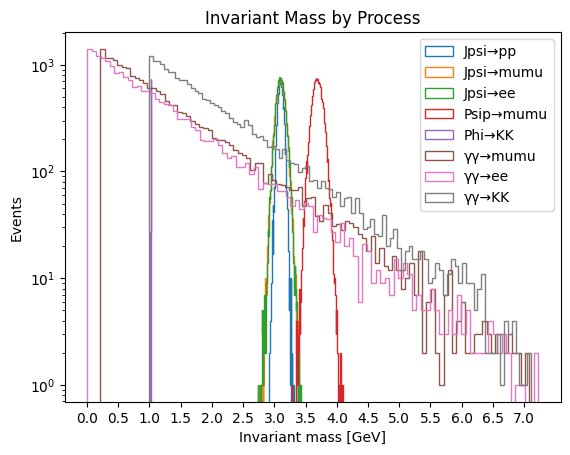

In [118]:
m2 = (
    (df_after["E1"] + df_after["E2"])**2
    - (df_after["px1"] + df_after["px2"])**2
    - (df_after["py1"] + df_after["py2"])**2
    - (df_after["pz1"] + df_after["pz2"])**2
)

df_after["m_inv"] = np.sqrt(np.maximum(m2, 0))

for proc in df_after["process"].unique():
    subset = df_after[df_after["process"] == proc]
    plt.hist(subset["m_inv"], bins=100, histtype="step", label=proc)

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Events")
plt.xticks(np.arange(0, 7.1, 0.5))
plt.yscale('log')
plt.legend()
plt.title("Invariant Mass by Process")
plt.show()

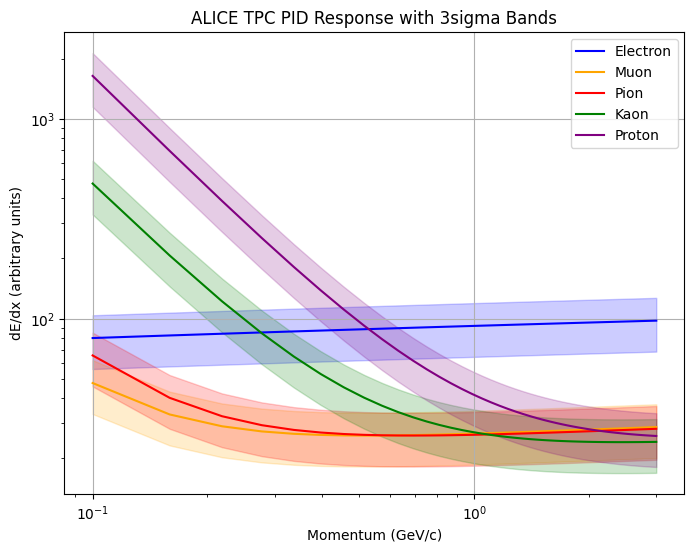

In [119]:
def bethe_bloch(momentum, mass, charge=1):
# Constants for Bethe-Bloch approximation
    K = 0.307075 # MeV mol^-1 cm^2
    Z = charge # Particle charge
    I = 0.000016 # Mean excitation potential (MeV)
    m_e = 0.511 # Electron mass in MeV/c^2
    rho = 1 # Density of the material (relative to water, for simplicity)

# Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

# Bethe-Bloch equation (simplified)
    dEdx = ((K * Z**2 * rho) / (beta**2) * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx

def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
    'electron': 0.000511,
    'muon': 0.10566,
    'pion': 0.13957,
    'kaon': 0.49367,
    'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass if not found
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3

    return dEdx, lower_band, upper_band

def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

def random_gaussian(mean, sigma):

    return np.random.normal(mean, sigma)

def gaussian_tpc_response(momentum, particle_type, stretch_factor):

    # Get the mean dE/dx from TPC PID response
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type,stretch_factor)

    # Calculate the extremes for the 3σ band
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)

    # Estimate σ as 1/3rd of the difference between the upper and lower bands
    sigma_dEdx = (upper_band - lower_band) / 6

    # Generate a random dE/dx value from a Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)

    return random_dEdx

    # Example usage
    momentum = .3 # Example momentum in GeV/c
    particle_type = 'proton' # Example particle type
    x=1000 #Amount of random numbers

    rn=[]
    for _ in range(x):

        if (particle_type == 'electron'):
            stretch_factor=1
        elif (particle_type == 'muon'):
            stretch_factor=.41
        elif (particle_type == 'pion'):
            stretch_factor=.41
        elif (particle_type == 'kaon'):
            stretch_factor=.38
        elif (particle_type == 'proton'):
            stretch_factor=.40

    random_value = gaussian_tpc_response(momentum, particle_type, stretch_factor)
    rn.append(random_value)

    print(rn)

    xvalues=[]
    for _ in range(x):
        xvalues.append(momentum)
    print(xvalues)

def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands for various particle types.
    """
    # Calculate responses and PID bands for different particle species
    particle_types = {
    'Electron': {'color': 'blue', 'stretch_factor': 1},
    'Muon': {'color': 'orange', 'stretch_factor': 0.41},
    'Pion': {'color': 'red', 'stretch_factor': 0.41},
    'Kaon': {'color': 'green', 'stretch_factor': 0.38},
    'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(8, 6))

    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)

# plt.plot(xvalues,rn, color= 'black')
momentum_range = np.linspace(0.1, 3) # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.xscale('log')  # Log scale for x-axis
plt.yscale('log')  # Log scale for y-axis
plt.title('ALICE TPC PID Response with 3sigma Bands')
plt.legend()
plt.grid(True)
plt.show()

#Generate a momentum range and plot
mass_dict = {
    'electron': 0.000511,
    'muon': 0.10566,
    'pion': 0.13957,
    'kaon': 0.49367,
    'proton': 0.93827
    }




electron 80.0309130202914 97.78387563690868
muon 26.04703247267319 47.681429386370816
pion 26.046765521951805 65.50112067319142
kaon 24.141054363234282 473.97899079403237
proton 25.91568887948957 1636.7405123619078


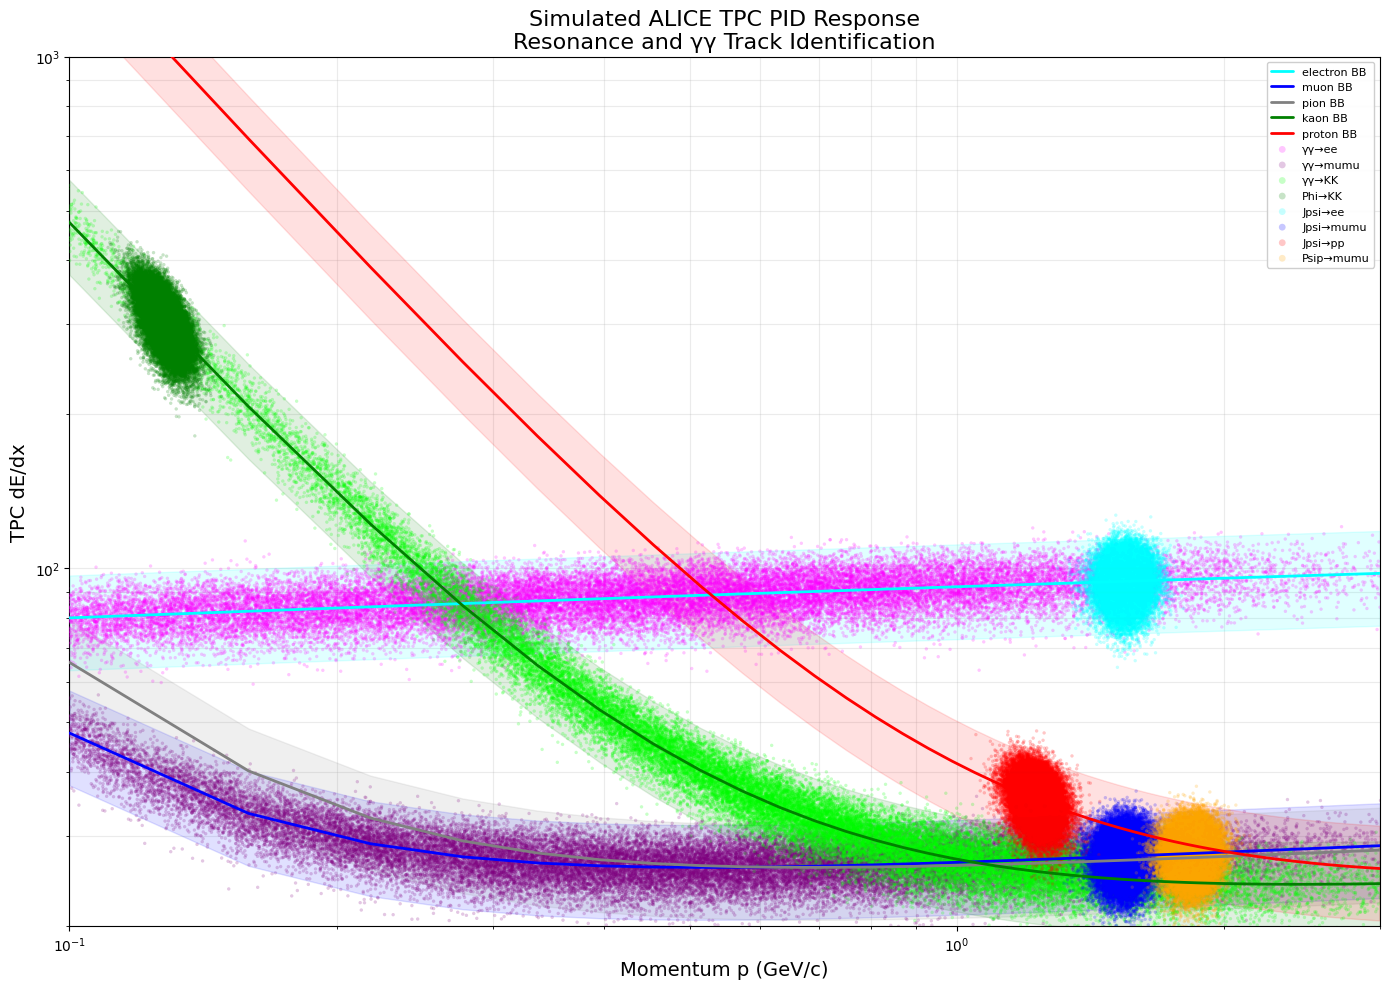


========== PID SUMMARY ==========

particle  identified
electron  electron      76694
          kaon           1088
          muon            453
          pion            516
          proton         1249
kaon      electron        853
          kaon          72240
          muon           3297
          pion           3234
          proton          376
muon      electron        263
          kaon          19459
          muon          41643
          pion          32397
          proton        26238
proton    kaon             24
          muon           1891
          pion             37
          proton        38048
dtype: int64


In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# BETHE-BLOCH TPC PID MODEL
# =========================================================

def bethe_bloch(momentum, mass, charge=1):

    K = 0.307075
    I = 0.000016
    m_e = 0.511
    rho = 1

    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    dEdx = (
        ((K * charge**2 * rho) / (beta**2))
        * (
            0.5 * np.log(
                2 * m_e * beta**2 * gamma**2 / I**2
            )
            - beta**2
        )
    ) * 17

    return dEdx


# =========================================================
# PARTICLE MASSES
# =========================================================

mass_dict = {
    'electron': 0.000511,
    'muon':     0.10566,
    'pion':     0.13957,
    'kaon':     0.49367,
    'proton':   0.93827
}

# Detector response scaling
stretch_dict = {
    'electron': 1.00,
    'muon':     0.41,
    'pion':     0.41,
    'kaon':     0.38,
    'proton':   0.40
}

# =========================================================
# COLORS FOR RESONANCES / TRACKS
# =========================================================

process_colors = {
    "Jpsi→pp": "red",
    "Jpsi→mumu": "blue",
    "Jpsi→ee": "cyan",
    "Psip→mumu": "orange",
    "Phi→KK": "green",
    "γγ→mumu": "purple",
    "γγ→ee": "magenta",
    "γγ→KK": "lime"
}

# =========================================================
# GENERATE TPC RESPONSE
# =========================================================

def generate_tpc_response(momentum, particle_type):

    mass = mass_dict[particle_type]
    stretch = stretch_dict[particle_type]

    mean = bethe_bloch(momentum, mass) * stretch

    sigma = 0.08 * mean

    measured = np.random.normal(mean, sigma)

    return measured, sigma


# =========================================================
# MAP PROCESSES TO PARTICLE TYPES
# =========================================================

pid_map = {
    "Jpsi→pp": "proton",
    "Jpsi→mumu": "muon",
    "Jpsi→ee": "electron",
    "Psip→mumu": "muon",
    "Phi→KK": "kaon",
    "γγ→mumu": "muon",
    "γγ→ee": "electron",
    "γγ→KK": "kaon"
}

# =========================================================
# BUILD TRACK DATASET
# =========================================================

track_data = []

for proc in df_after["process"].unique():

    sub = df_after[df_after["process"] == proc]

    particle_type = pid_map[proc]

    # Track 1
    p1 = np.sqrt(
        sub["px1"]**2 +
        sub["py1"]**2 +
        sub["pz1"]**2
    )

    # Track 2
    p2 = np.sqrt(
        sub["px2"]**2 +
        sub["py2"]**2 +
        sub["pz2"]**2
    )

    # Generate TPC response
    dedx1 = []
    dedx2 = []

    for mom in p1:
        d, s = generate_tpc_response(mom, particle_type)
        dedx1.append(d)

    for mom in p2:
        d, s = generate_tpc_response(mom, particle_type)
        dedx2.append(d)

    temp1 = pd.DataFrame({
        "process": proc,
        "particle": particle_type,
        "momentum": p1,
        "dEdx": dedx1
    })

    temp2 = pd.DataFrame({
        "process": proc,
        "particle": particle_type,
        "momentum": p2,
        "dEdx": dedx2
    })

    track_data.append(temp1)
    track_data.append(temp2)

# Combined PID dataset
pid_df = pd.concat(track_data, ignore_index=True)

# =========================================================
plot_priority = [
    "γγ→ee",
    "γγ→mumu",
    "γγ→KK",
    "Phi→KK",
    "Jpsi→ee",
    "Jpsi→mumu",
    "Jpsi→pp",
    "Psip→mumu"
]

# ---------------------------------------------------------
# Plot tracks with controlled layering
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))

process_colors = {
    "Jpsi→pp": "red",
    "Jpsi→mumu": "blue",
    "Jpsi→ee": "cyan",
    "Psip→mumu": "orange",
    "Phi→KK": "green",
    "γγ→mumu": "purple",
    "γγ→ee": "magenta",
    "γγ→KK": "lime"
}

particle_colors = {
    "electron": "cyan",
    "muon": "blue",
    "pion": "gray",
    "kaon": "green",
    "proton": "red"
}

# ---------------------------------------------------------
# CENTRAL BETHE-BLOCH CURVES
# ---------------------------------------------------------

for particle in mass_dict.keys():

    mass = mass_dict[particle]
    stretch = stretch_dict[particle]

    curve = bethe_bloch(momentum_range, mass) * stretch

    sigma_fraction = 0.07
    band = 3 * sigma_fraction * curve

    # --- 3σ shaded region ---
    plt.fill_between(
    momentum_range,
    curve - band,
    curve + band,
    color=particle_colors[particle],
    alpha=0.12,
    zorder=2
)

    # Debug visibility
    print(particle, np.nanmin(curve), np.nanmax(curve))

    plt.plot(
        momentum_range,
        curve,
        color=particle_colors[particle],
        linewidth=2,          # thicker
        linestyle='-',
        alpha=1.0,
        zorder=1000,          # VERY high priority
        solid_capstyle='round',
        label=f"{particle} BB"
    )
for layer, proc in enumerate(plot_priority):

    sub = pid_df[pid_df["process"] == proc].copy()

    # Helps prevent overdrawing artifacts
    sub = sub.sort_values("dEdx")

    plt.scatter(
        sub["momentum"],
        sub["dEdx"],
        s=6,
        alpha=0.22,
        color=process_colors[proc],
        edgecolors='none',
        rasterized=True,
        label=proc,
        zorder=10 + layer
    )

# =========================================================
# STYLE
# =========================================================

plt.xscale("log")
plt.yscale("log")

plt.xlim(0.1, 3)
plt.ylim(20, 1000)

plt.xlabel("Momentum p (GeV/c)", fontsize=14)
plt.ylabel("TPC dE/dx", fontsize=14)

plt.title(
    "Simulated ALICE TPC PID Response\n"
    "Resonance and γγ Track Identification",
    fontsize=16
)

plt.grid(True, which="both", alpha=0.25)

# cleaner legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

plt.legend(
    by_label.values(),
    by_label.keys(),
    fontsize=8,
    loc="upper right",
    framealpha=0.95,
    markerscale=2
)

plt.tight_layout()
plt.show()
# =========================================================
# OPTIONAL: PID CLASSIFICATION
# =========================================================

def identify_particle(momentum, measured_dEdx):

    chi2_results = {}

    for particle in mass_dict.keys():

        mass = mass_dict[particle]
        stretch = stretch_dict[particle]

        expected = (
            bethe_bloch(momentum, mass)
            * stretch
        )

        sigma = 0.08 * expected

        chi2 = (
            (measured_dEdx - expected) / sigma
        )**2

        chi2_results[particle] = chi2

    best_particle = min(
        chi2_results,
        key=chi2_results.get
    )

    return best_particle


# =========================================================
# RUN PID IDENTIFICATION
# =========================================================

pid_df["identified"] = pid_df.apply(
    lambda row: identify_particle(
        row["momentum"],
        row["dEdx"]
    ),
    axis=1
)

# =========================================================
# EFFICIENCY SUMMARY
# =========================================================

print("\n========== PID SUMMARY ==========\n")

summary = (
    pid_df.groupby(
        ["particle", "identified"]
    ).size()
)

print(summary)

In [121]:
#EventId/Particle/Nsigmas:electron,muon,pion,kaon,proton. N sigmas < 0.5
#Grabit by ID sum the canditdates/number of tracks

In [122]:
# =========================================================
# CREATE PID N-SIGMA TABLE
# =========================================================

import numpy as np
import pandas as pd

# =========================================================
# REFERENCE CUT
# =========================================================

N_ref = 0.5

# =========================================================
# EVENT IDS
# =========================================================

# one event id per decay pair
df_after = df_after.reset_index(drop=True)
df_after["event_id"] = np.arange(len(df_after))

# =========================================================
# PID HYPOTHESES
# =========================================================

pid_particles = [
    "proton",
    "kaon",
    "pion",
    "electron",
    "muon"
]

# =========================================================
# PROCESS → TRUE TRACK PARTICLE
# =========================================================

pid_map = {
    "Jpsi→pp": "proton",
    "Jpsi→mumu": "muon",
    "Jpsi→ee": "electron",
    "Psip→mumu": "muon",
    "Phi→KK": "kaon",
    "γγ→mumu": "muon",
    "γγ→ee": "electron",
    "γγ→KK": "kaon"
}

# =========================================================
# COMPUTE N-SIGMAS
# =========================================================

table_rows = []

for idx, row in df_after.iterrows():

    process = row["process"]

    # ---------------------------------------------
    # TRUE particle type
    # ---------------------------------------------

    true_particle = pid_map[process]

    # ---------------------------------------------
    # BOTH TRACKS (+ and -)
    # ---------------------------------------------

    for track in [1, 2]:

        px = row[f"px{track}"]
        py = row[f"py{track}"]
        pz = row[f"pz{track}"]

        momentum = np.sqrt(px**2 + py**2 + pz**2)

        # -----------------------------------------
        # Simulated measured dE/dx
        # -----------------------------------------

        measured_dEdx, sigma_measured = generate_tpc_response(
            momentum,
            true_particle
        )

        # -----------------------------------------
        # Build row
        # -----------------------------------------

        result = {
            "event_id": row["event_id"],
            "track": f"{track}",
            "process": process,
            "true_particle": true_particle,
            "px": px,
            "py": py,
            "pz": pz,
            "p": momentum,
            "measured_dEdx": measured_dEdx
        }

        # -----------------------------------------
        # Compute N_sigma for each PID hypothesis
        # -----------------------------------------

        for particle in pid_particles:

            mass = mass_dict[particle]
            stretch = stretch_dict[particle]

            expected = (
                bethe_bloch(momentum, mass)
                * stretch
            )

            sigma = 0.08 * expected

            n_sigma = (
                measured_dEdx - expected
            ) / sigma

            abs_nsigma = abs(n_sigma)

            # Save N_sigma
            result[f"Nsigma_{particle}"] = abs_nsigma

            # PID cut test
            result[f"{particle}_PID"] = (
                1 if abs_nsigma < N_ref else 0
            )

        table_rows.append(result)

# =========================================================
# FINAL PID TABLE
# =========================================================

pid_table = pd.DataFrame(table_rows)

# =========================================================
# ROUND VALUES
# =========================================================

float_cols = [
    "px", "py", "pz", "p",
    "measured_dEdx"
]

for col in float_cols:
    pid_table[col] = pid_table[col].round(4)

for particle in pid_particles:
    pid_table[f"Nsigma_{particle}"] = (
        pid_table[f"Nsigma_{particle}"]
        .round(3)
    )

# =========================================================
# DISPLAY TABLE
# =========================================================

print("\n================ PID TABLE ================\n")

print(
    pid_table[
        [
            "event_id",
            "track",
            "process",
            "true_particle",

            "px",
            "py",
            "pz",
            "p",

            "Nsigma_proton",
            "proton_PID",

            "Nsigma_kaon",
            "kaon_PID",

            "Nsigma_pion",
            "pion_PID",

            "Nsigma_electron",
            "electron_PID",

            "Nsigma_muon",
            "muon_PID"
        ]
    ].head(20)
)

# =========================================================
# OPTIONAL: SAVE TABLE
# =========================================================

pid_table.to_csv(
    "alice_tpc_pid_table.csv",
    index=False
)

print("\nSaved: alice_tpc_pid_table.csv")


================ PID TABLE ================

    event_id track  process true_particle      px      py      pz       p  \
0          0     1  Jpsi→pp        proton  0.6354  0.8398  0.4946  1.1634   
1          0     2  Jpsi→pp        proton -0.6172 -1.0018 -0.4758  1.2692   
2          1     1  Jpsi→pp        proton  0.1846 -1.1162 -0.5675  1.2657   
3          1     2  Jpsi→pp        proton -0.1748  1.0371  0.5423  1.1833   
4          2     1  Jpsi→pp        proton  0.8255  0.8063  0.4883  1.2530   
5          2     2  Jpsi→pp        proton -0.8665 -0.7667 -0.4803  1.2528   
6          3     1  Jpsi→pp        proton -0.0741 -0.4987  1.1551  1.2603   
7          3     2  Jpsi→pp        proton  0.0732  0.5237 -1.0668  1.1907   
8          4     1  Jpsi→pp        proton  1.0878 -0.0667  0.2888  1.1275   
9          4     2  Jpsi→pp        proton -1.2321  0.0687 -0.3149  1.2736   
10         5     1  Jpsi→pp        proton  1.0679 -0.2803 -0.5557  1.2360   
11         5     2  Jpsi→pp   

In [123]:
# =========================================================
# INPUT: pid_table (from previous step)
# =========================================================

pid_df = pid_table.copy()

pid_particles = ["proton", "kaon", "pion", "electron", "muon"]

# =========================================================
# EVENT LEVEL GROUPING
# =========================================================

event_rows = []

for event_id, group in pid_df.groupby("event_id"):

    event_result = {
        "event_id": event_id,
        "n_tracks": 2   # fixed by construction
    }

    # -----------------------------------------------------
    # SUM PID FLAGS OVER TRACKS
    # -----------------------------------------------------

    for particle in pid_particles:

        col = f"{particle}_PID"

        # sum of 0/1 over 2 tracks → range [0,2]
        pid_sum = group[col].sum()

        event_result[f"{particle}_PID_sum"] = pid_sum

        # optional: event-level decision (both tracks pass)
        #event_result[f"{particle}_FULL_MATCH"] = (
        #    1 if pid_sum == 2 else 0
        #)

        # optional: at least one track passes
        #event_result[f"{particle}_ANY_MATCH"] = (
           # 1 if pid_sum >= 1 else 0
        #)

    event_rows.append(event_result)

# =========================================================
# FINAL EVENT TABLE
# =========================================================

event_table = pd.DataFrame(event_rows)

# =========================================================
# DISPLAY CLEAN VIEW
# =========================================================

print("\n================ EVENT LEVEL PID SUMMARY ================\n")

print(event_table.head(20))

# =========================================================
# OPTIONAL: SAVE
# =========================================================

event_table.to_csv("alice_event_pid_summary.csv", index=False)

print("\nSaved: alice_event_pid_summary.csv")


================ EVENT LEVEL PID SUMMARY ================

    event_id  n_tracks  proton_PID_sum  kaon_PID_sum  pion_PID_sum  \
0          0         2               0             0             0   
1          1         2               1             0             0   
2          2         2               0             0             0   
3          3         2               1             0             0   
4          4         2               0             0             0   
5          5         2               0             0             0   
6          6         2               0             0             0   
7          7         2               1             0             0   
8          8         2               1             0             0   
9          9         2               0             0             0   
10        10         2               0             0             0   
11        11         2               1             0             0   
12        12         2        

In [124]:
# =========================================================
# REAL DATA GENERATION 
# =========================================================



# ADD PROCESES FIX CODE!



# =========================================================
# NEW PROCESS SET FOR ALL 2 PARTICLE DECAYS
# =========================================================

process_list = [
    "γγ→ee",
    "γγ→mumu",
    "γγ→KK",
    "Jpsi→ee",
    "Jpsi→mumu",
    "Psip→mumu"
]

df_ext = df_after[df_after["process"].isin(process_list)].copy()
df_ext = df_ext.reset_index(drop=True)

# assign event ids again (clean separation for training set)
df_ext["event_id"] = np.arange(len(df_ext))

# =========================================================
# PID SETUP (EXTENDED IF NEEDED)
# =========================================================

pid_particles = ["proton", "kaon", "pion", "electron", "muon",]

pid_map = {
    "γγ→ee": "electron",
    "γγ→mumu": "muon",
    "γγ→KK": "kaon",
    "Jpsi→ee": "electron",
    "Jpsi→mumu": "muon",
    "Psip→mumu": "muon"
}

N_ref = 0.5

# =========================================================
# BUILD TRACK-LEVEL TABLE
# =========================================================

rows = []

for _, row in df_ext.iterrows():

    process = row["process"]
    true_particle = pid_map[process]

    for track in [1, 2]:

        px = row[f"px{track}"]
        py = row[f"py{track}"]
        pz = row[f"pz{track}"]

        momentum = np.sqrt(px**2 + py**2 + pz**2)

        measured_dEdx, _ = generate_tpc_response(momentum, true_particle)

        out = {
            "event_id": row["event_id"],
            "track": track,
            "process": process,
            "true_particle": true_particle,
            "px": px,
            "py": py,
            "pz": pz,
            "p": momentum,
            "measured_dEdx": measured_dEdx
        }

        for particle in pid_particles:

            expected = bethe_bloch(momentum, mass_dict[particle]) * stretch_dict[particle]
            sigma = 0.08 * expected

            n_sigma = abs((measured_dEdx - expected) / sigma)

            out[f"Nsigma_{particle}"] = round(n_sigma, 3)
            out[f"{particle}_PID"] = int(n_sigma < N_ref)

        rows.append(out)

pid_table_ext = pd.DataFrame(rows)

# =========================================================
# ROUNDING
# =========================================================

for col in ["px", "py", "pz", "p", "measured_dEdx"]:
    pid_table_ext[col] = pid_table_ext[col].round(4)

# =========================================================
# EVENT-LEVEL SUMMARY
# =========================================================

event_rows = []

for eid, group in pid_table_ext.groupby("event_id"):

    event_out = {
        "event_id": eid,
        "n_tracks": len(group)
    }

    for particle in pid_particles:
        event_out[f"{particle}_PID_sum"] = group[f"{particle}_PID"].sum()

    event_rows.append(event_out)

event_table_ext = pd.DataFrame(event_rows)

# =========================================================
# DISPLAY TABLES (like previous cells)
# =========================================================

print("\n================ EXTENDED PID TABLE ================\n")
print(pid_table_ext.head(20))

print("\n================ EXTENDED EVENT SUMMARY ================\n")
print(event_table_ext.head(20))

# =========================================================
# SAVE CSV FILES
# =========================================================

pid_table_ext.to_csv("training_pid_table.csv", index=False)
event_table_ext.to_csv("training_event_summary.csv", index=False)

print("\nSaved: training_pid_table.csv")
print("Saved: training_event_summary.csv")


================ EXTENDED PID TABLE ================

    event_id  track    process true_particle      px      py      pz       p  \
0          0      1  Jpsi→mumu          muon  1.0244 -0.6673  0.9820  1.5681   
1          0      2  Jpsi→mumu          muon -0.9702  0.7413 -0.8531  1.4895   
2          1      1  Jpsi→mumu          muon -0.2023  1.5949  0.2654  1.6294   
3          1      2  Jpsi→mumu          muon  0.1929 -1.5966 -0.2571  1.6286   
4          2      1  Jpsi→mumu          muon  0.6690  1.1382 -0.7879  1.5375   
5          2      2  Jpsi→mumu          muon -0.6860 -1.0796  0.7786  1.4975   
6          3      1  Jpsi→mumu          muon -0.2538 -1.0149  1.1633  1.5645   
7          3      2  Jpsi→mumu          muon  0.2603  1.0176 -1.1147  1.5316   
8          4      1  Jpsi→mumu          muon -1.5021 -0.4550 -0.2477  1.5889   
9          4      2  Jpsi→mumu          muon  1.4687  0.4371  0.2444  1.5517   
10         5      1  Jpsi→mumu          muon -0.0459  0.5977 -1.3

In [ ]:
# =========================================================
# REAL DATA CELL: n = 100 per process
# Creates:
#   real_data_without_pentaquark.csv
#   real_data_with_pentaquark.csv
# Adds invariant mass columns
# =========================================================

import numpy as np
import pandas as pd

np.random.seed(42)

N_REAL = 100
N_ref = 0.5
pid_particles = ["proton", "kaon", "pion", "electron", "muon"]

# ---------------------------------------------------------
# Add Pentaquark mass
# ---------------------------------------------------------

masses["Pc4360"] = 4.360


# ---------------------------------------------------------
# Safe helper functions
# These avoid using names like energy/momentum that may have
# been overwritten earlier in the notebook.
# ---------------------------------------------------------

def two_body_energy(parent_mass, daughter_mass, other_mass):
    return (
        parent_mass**2
        + daughter_mass**2
        - other_mass**2
    ) / (2 * parent_mass)


def two_body_momentum(parent_mass, m1, m2):
    E1 = two_body_energy(parent_mass, m1, m2)
    return np.sqrt(np.maximum(E1**2 - m1**2, 0))


def invariant_mass_from_tracks(row, tracks):
    E = sum(row[f"E{i}"] for i in tracks)
    px = sum(row[f"px{i}"] for i in tracks)
    py = sum(row[f"py{i}"] for i in tracks)
    pz = sum(row[f"pz{i}"] for i in tracks)

    m2 = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(max(m2, 0))


def boost(px, py, pz, E, bx, by, bz):
    b2 = bx**2 + by**2 + bz**2
    gamma = 1 / np.sqrt(1 - b2)

    bp = bx*px + by*py + bz*pz
    gamma2 = np.where(b2 > 0, (gamma - 1) / b2, 0)

    px_b = px + gamma2*bp*bx + gamma*bx*E
    py_b = py + gamma2*bp*by + gamma*by*E
    pz_b = pz + gamma2*bp*bz + gamma*bz*E
    E_b = gamma * (E + bp)

    return E_b, px_b, py_b, pz_b


# ---------------------------------------------------------
# P_c(4360) -> J/psi + proton, J/psi -> mu+ mu-
# ---------------------------------------------------------

def pc4360_to_jpsi_proton_to_mumu_p(n):
    """
    P_c(4360) -> J/psi + proton
    J/psi -> mu+ mu-

    Final state:
        track 1 = mu+
        track 2 = mu-
        track 3 = proton
    """

    mPc = masses["Pc4360"]
    mJ = masses["Jpsi"]
    mp = masses["p"]
    mmu = masses["mu"]

    EJ = two_body_energy(mPc, mJ, mp)
    Ep = two_body_energy(mPc, mp, mJ)
    pJ = two_body_momentum(mPc, mJ, mp)

    theta, phi = generate_angles(n)

    pxJ = pJ * np.sin(theta) * np.cos(phi)
    pyJ = pJ * np.sin(theta) * np.sin(phi)
    pzJ = pJ * np.cos(theta)

    pxp = -pxJ
    pyp = -pyJ
    pzp = -pzJ

    Emu = mJ / 2
    pmu = np.sqrt(np.maximum(Emu**2 - mmu**2, 0))

    theta2, phi2 = generate_angles(n)

    px_mu = pmu * np.sin(theta2) * np.cos(phi2)
    py_mu = pmu * np.sin(theta2) * np.sin(phi2)
    pz_mu = pmu * np.cos(theta2)

    bx = pxJ / EJ
    by = pyJ / EJ
    bz = pzJ / EJ

    E1, px1, py1, pz1 = boost(
        px_mu, py_mu, pz_mu, Emu,
        bx, by, bz
    )

    E2, px2, py2, pz2 = boost(
        -px_mu, -py_mu, -pz_mu, Emu,
        bx, by, bz
    )

    return pd.DataFrame({
        "process": "Pc4360→Jpsi_p→mumu_p",

        "E1": E1,
        "px1": px1,
        "py1": py1,
        "pz1": pz1,

        "E2": E2,
        "px2": px2,
        "py2": py2,
        "pz2": pz2,

        "E3": Ep,
        "px3": pxp,
        "py3": pyp,
        "pz3": pzp,
    })


# ---------------------------------------------------------
# Smearing and energy recomputation
# ---------------------------------------------------------

def smear_real_momenta(df, sigma_rel=0.04):
    df = df.copy()

    for track in [1, 2, 3]:
        for comp in ["px", "py", "pz"]:
            col = f"{comp}{track}"

            if col not in df.columns:
                continue

            mask = df[col].notna()

            sigma = sigma_rel * np.abs(df.loc[mask, col])

            df.loc[mask, col] = np.random.normal(
                df.loc[mask, col],
                sigma
            )

    return df


def recompute_real_energies(df):
    df = df.copy()

    particle_tracks = {
        "γγ→ee": ["electron", "electron"],
        "γγ→mumu": ["muon", "muon"],
        "γγ→KK": ["kaon", "kaon"],

        "Jpsi→ee": ["electron", "electron"],
        "Jpsi→mumu": ["muon", "muon"],
        "Jpsi→ppbar": ["proton", "proton"],

        "Psip→mumu": ["muon", "muon"],

        "Pc4360→Jpsi_p→mumu_p": ["muon", "muon", "proton"]
    }

    for proc, particles in particle_tracks.items():
        mask_proc = df["process"] == proc

        for i, particle in enumerate(particles, start=1):

            needed_cols = [f"px{i}", f"py{i}", f"pz{i}"]

            if not all(col in df.columns for col in needed_cols):
                continue

            mask = mask_proc & df[f"px{i}"].notna()

            p2 = (
                df.loc[mask, f"px{i}"]**2 +
                df.loc[mask, f"py{i}"]**2 +
                df.loc[mask, f"pz{i}"]**2
            )

            df.loc[mask, f"E{i}"] = np.sqrt(
                p2 + mass_dict[particle]**2
            )

    return df


# ---------------------------------------------------------
# Generate 2-body real data
# ---------------------------------------------------------
def safe_two_body_decay(n, parent_mass, m1, m2, process_name):
    E1 = two_body_energy(parent_mass, m1, m2)
    E2 = two_body_energy(parent_mass, m2, m1)
    p = two_body_momentum(parent_mass, m1, m2)

    theta, phi = generate_angles(n)

    px1 = p * np.sin(theta) * np.cos(phi)
    py1 = p * np.sin(theta) * np.sin(phi)
    pz1 = p * np.cos(theta)

    px2 = -px1
    py2 = -py1
    pz2 = -pz1

    return pd.DataFrame({
        "process": process_name,

        "E1": E1,
        "px1": px1,
        "py1": py1,
        "pz1": pz1,

        "E2": E2,
        "px2": px2,
        "py2": py2,
        "pz2": pz2,
    })

real_2body = [
    gamma_gamma_to_pair(N_REAL, masses["e"],  "γγ→ee"),
    gamma_gamma_to_pair(N_REAL, masses["mu"], "γγ→mumu"),
    gamma_gamma_to_pair(N_REAL, masses["K"],  "γγ→KK"),

    safe_two_body_decay(N_REAL, masses["Jpsi"], masses["e"],  masses["e"],  "Jpsi→ee"),
    safe_two_body_decay(N_REAL, masses["Jpsi"], masses["mu"], masses["mu"], "Jpsi→mumu"),

    safe_two_body_decay(N_REAL, masses["Psip"], masses["mu"], masses["mu"], "Psip→mumu"),
]
real_without_pc = pd.concat(real_2body, ignore_index=True)

real_with_pc = pd.concat(
    real_2body + [pc4360_to_jpsi_proton_to_mumu_p(N_REAL)],
    ignore_index=True
)


# ---------------------------------------------------------
# Apply real-data detector smearing
# ---------------------------------------------------------

real_without_pc = smear_real_momenta(real_without_pc, sigma_rel=0.04)
real_without_pc = recompute_real_energies(real_without_pc)

real_with_pc = smear_real_momenta(real_with_pc, sigma_rel=0.04)
real_with_pc = recompute_real_energies(real_with_pc)


# ---------------------------------------------------------
# Build event-level PID tables
# ---------------------------------------------------------

true_track_particles = {
    "γγ→ee": ["electron", "electron"],
    "γγ→mumu": ["muon", "muon"],
    "γγ→KK": ["kaon", "kaon"],

    "Jpsi→ee": ["electron", "electron"],
    "Jpsi→mumu": ["muon", "muon"],
    "Jpsi→ppbar": ["proton", "proton"],

    "Psip→mumu": ["muon", "muon"],

    "Pc4360→Jpsi_p→mumu_p": ["muon", "muon", "proton"]
}


def build_real_event_table(df):
    df = df.copy()
    df["event_id"] = np.arange(len(df))

    event_rows = []

    for _, row in df.iterrows():

        proc = row["process"]
        particles = true_track_particles[proc]
        n_tracks = len(particles)

        event_out = {
            "event_id": row["event_id"],
            "process": proc,
            "n_tracks": n_tracks,
            "m_inv_pair": invariant_mass_from_tracks(row, [1, 2]),
        }

        if n_tracks == 3:
            event_out["m_inv_3body"] = invariant_mass_from_tracks(row, [1, 2, 3])
        else:
            event_out["m_inv_3body"] = np.nan

        for particle in pid_particles:
            event_out[f"{particle}_PID_sum"] = 0

        for track, true_particle in enumerate(particles, start=1):

            px = row[f"px{track}"]
            py = row[f"py{track}"]
            pz = row[f"pz{track}"]

            p = np.sqrt(px**2 + py**2 + pz**2)

            measured_dEdx, _ = generate_tpc_response(p, true_particle)

            event_out[f"track{track}_true_particle"] = true_particle
            event_out[f"track{track}_px"] = px
            event_out[f"track{track}_py"] = py
            event_out[f"track{track}_pz"] = pz
            event_out[f"track{track}_p"] = p
            event_out[f"track{track}_measured_dEdx"] = measured_dEdx

            for particle in pid_particles:
                expected = bethe_bloch(p, mass_dict[particle]) * stretch_dict[particle]
                sigma = 0.08 * expected

                n_sigma = abs((measured_dEdx - expected) / sigma)

                event_out[f"track{track}_Nsigma_{particle}"] = n_sigma

                passed = int(n_sigma < N_ref)
                event_out[f"track{track}_{particle}_PID"] = passed
                event_out[f"{particle}_PID_sum"] += passed

        event_rows.append(event_out)

    out = pd.DataFrame(event_rows)

    keep_cols = [
        "event_id",
        "process",
        "n_tracks",
        "proton_PID_sum",
        "kaon_PID_sum",
        "pion_PID_sum",
        "electron_PID_sum",
        "muon_PID_sum",
        "m_inv_pair",
        "m_inv_3body"
    ]
    out = out[keep_cols]

    float_cols = out.select_dtypes(include=[float]).columns
    out[float_cols] = out[float_cols].round(5)

    return out


real_data_without_pc = build_real_event_table(real_without_pc)
real_data_with_pc = build_real_event_table(real_with_pc)

real_data_without_pc = real_data_without_pc.drop(columns=["m_inv_3body"])

real_data_with_pc["m_inv_pair"] = real_data_with_pc["m_inv_3body"].fillna(
    real_data_with_pc["m_inv_pair"]
)
real_data_with_pc = real_data_with_pc.drop(columns=["m_inv_3body"])

real_data_without_pc.to_csv("real_data_without_pentaquark.csv", index=False)
real_data_with_pc.to_csv("real_data_with_pentaquark.csv", index=False)

print("Saved: real_data_without_pentaquark.csv")
print("Saved: real_data_with_pentaquark.csv")

print(real_data_without_pc.head())
print(real_data_with_pc.tail())


# =========================================================
# ADD PAIR INVARIANT MASS TO PREVIOUS CSV FILES
# =========================================================

df_after["m_inv_pair"] = df_after.apply(
    lambda row: invariant_mass_from_tracks(row, [1, 2]),
    axis=1
)

if "event_id" not in df_after.columns:
    df_after = df_after.reset_index(drop=True)
    df_after["event_id"] = np.arange(len(df_after))

try:
    old_event = pd.read_csv("alice_event_pid_summary.csv")

    mass_lookup = df_after[["event_id", "m_inv_pair"]].copy()

    old_event = old_event.merge(
        mass_lookup,
        on="event_id",
        how="left"
    )

    old_event.to_csv("alice_event_pid_summary_with_m_inv.csv", index=False)

    print("Saved: alice_event_pid_summary_with_m_inv.csv")

except FileNotFoundError:
    print("alice_event_pid_summary.csv not found, skipped.")


try:
    old_training = pd.read_csv("training_event_summary.csv")

    mass_lookup = df_after[["event_id", "m_inv_pair"]].copy()

    old_training = old_training.merge(
        mass_lookup,
        on="event_id",
        how="left"
    )

    old_training.to_csv("training_event_summary_with_m_inv.csv", index=False)

    print("Saved: training_event_summary_with_m_inv.csv")

except FileNotFoundError:
    print("training_event_summary.csv not found, skipped.")

Saved: real_data_without_pentaquark.csv
Saved: real_data_with_pentaquark.csv
   event_id process  n_tracks  proton_PID_sum  kaon_PID_sum  pion_PID_sum  \
0         0   γγ→ee         2               0             0             0   
1         1   γγ→ee         2               0             0             0   
2         2   γγ→ee         2               0             0             0   
3         3   γγ→ee         2               0             0             0   
4         4   γγ→ee         2               0             0             0   

   electron_PID_sum  muon_PID_sum  m_inv_pair  
0                 0             0     0.45619  
1                 0             0     2.94173  
2                 2             0     1.35351  
3                 2             0     0.90735  
4                 0             0     0.16953  
     event_id               process  n_tracks  proton_PID_sum  kaon_PID_sum  \
795       795  Pc4360→Jpsi_p→mumu_p         3               1             0   
796       796 

In [126]:
# GOD Please let it work for once